# Football-LLM · Notebook 5 · Consistency Analysis

**ECE 590.09 Final Project · Zanwen Fu**

The fifth and final analysis notebook. No training, no generation — this is pure re-analysis of the JSON files produced by `03_icl_cot_baselines.ipynb`, `03b_cot_rerun.ipynb`, and `04_scaling_ablation.ipynb`.

**Purpose:** produce the evidence base for the central finding of the report — that fine-tuning on 192 examples teaches the model the *structure* of the Prediction/Score/Reasoning format but not the *binding* between these fields, and that standard accuracy metrics (which use "score overrides text") mask this.

**Outputs:**
- `consistency_table.csv` / `consistency_table.json` — per-condition: score-accuracy, text-label accuracy, text/score agreement, home-win prediction rate
- `consistency_curve.png` — the new headline figure: internal consistency vs data budget
- `example_contradictions.md` — hand-curated examples of the three failure types (for the report)
- `final_tables.json` — all numbers consolidated, one source of truth for the report

**Runtime:** a few minutes. No GPU needed.

**This notebook is safe to run locally too** (not just Colab) since it's just data analysis. If running locally, place the JSON files in the same directory as the notebook.


## 1. Setup

In [1]:
import json, re, os
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Expected files — from nb3, nb3b, nb4. If running on Colab, upload these or mount Drive.
EXPECTED = [
    'icl_results.json',
    'cot_results_v2.json',
    'scaling_eval_n48.json',
    'scaling_eval_n96.json',
    'scaling_eval_n192.json',
    'scaling_eval_n384.json',
]
for f in EXPECTED:
    ok = os.path.exists(f)
    print(f"  {'OK ' if ok else 'MISS'} {f}")


  MISS icl_results.json
  MISS cot_results_v2.json
  MISS scaling_eval_n48.json
  MISS scaling_eval_n96.json
  MISS scaling_eval_n192.json
  MISS scaling_eval_n384.json


## 2. Load and standardize results

All six result files share the same schema after 03b/04 standardization. We load them into one dict and add a few derived fields.


In [3]:
def load_results(path):
    with open(path) as f:
        return json.load(f)

results = {
    'ICL':   load_results('icl_results.json'),
    'CoT':   load_results('cot_results_v2.json'),
    'n48':   load_results('scaling_eval_n48.json'),
    'n96':   load_results('scaling_eval_n96.json'),
    'n192':  load_results('scaling_eval_n192.json'),
    'n384':  load_results('scaling_eval_n384.json'),
}

for name, data in results.items():
    print(f"{name}: {len(data)} samples")


ICL: 128 samples
CoT: 128 samples
n48: 128 samples
n96: 128 samples
n192: 128 samples
n384: 128 samples


In [4]:
def extract_text_label(text):
    """Extract the label from 'Prediction: X' line (ignores Score: line).
    Returns one of {'home_win', 'away_win', 'draw', None}."""
    tl = text.lower()
    m = re.search(r'prediction[:\s]+(.*?)(?:\n|$)', tl)
    if not m:
        return None
    pt = m.group(1).strip()
    if 'draw' in pt: return 'draw'
    if 'home' in pt or 'team a' in pt: return 'home_win'
    if 'away' in pt or 'team b' in pt: return 'away_win'
    if 'win' in pt: return 'has_winner'
    return None


def extract_score_label(text):
    """Extract label from 'Score: N-M' line. Score always wins when found."""
    m = re.search(r'score[:\s]+.*?(\d+)\s*[-\u2013]\s*(\d+)', text, re.IGNORECASE)
    if not m:
        return None, None, None
    h, a = int(m.group(1)), int(m.group(2))
    if h > 15 or a > 15:
        return None, None, None
    if h > a: return 'home_win', h, a
    if h < a: return 'away_win', h, a
    return 'draw', h, a


def extract_reasoning_label(text):
    """Heuristic: infer which team the Reasoning paragraph ARGUES FOR by pattern-matching
    explicit 'X has higher / more / better' phrases. This is noisy but gives us a third
    view of what the model 'thinks'."""
    tl = text.lower()
    # Find the reasoning block
    rm = re.search(r'reasoning[:\s]+(.*)', tl, re.DOTALL)
    reasoning = rm.group(1) if rm else tl  # fallback: whole text (CoT's step text)

    # Count 'home stronger' vs 'away stronger' phrasings
    home_markers = ['team a\'s squad has higher', 'team a has higher', 'team a\'s top scorer is more',
                    'team a is more prolific', 'team a leads', 'home\'s squad has higher',
                    'team a has better', 'team a has more']
    away_markers = ['team b\'s squad has higher', 'team b has higher', 'team b\'s top scorer is more',
                    'team b is more prolific', 'team b leads', 'away\'s squad has higher',
                    'team b has better', 'team b has more']
    home_count = sum(reasoning.count(m) for m in home_markers)
    away_count = sum(reasoning.count(m) for m in away_markers)

    if home_count > away_count and home_count > 0:
        return 'home_argued'
    if away_count > home_count and away_count > 0:
        return 'away_argued'
    return 'unclear'


# Annotate every result with the three views
for cond, data in results.items():
    for r in data:
        raw = r['raw_output']
        r['text_label'] = extract_text_label(raw)
        score_lbl, h, a = extract_score_label(raw)
        r['score_label'] = score_lbl or r['pred'].get('result')  # fallback to parser's result
        r['reasoning_arg'] = extract_reasoning_label(raw)

# Sanity check
for cond, data in results.items():
    n_text = sum(1 for r in data if r['text_label'] in ('home_win', 'away_win', 'draw'))
    n_score = sum(1 for r in data if r['score_label'] in ('home_win', 'away_win', 'draw'))
    n_reasoning = sum(1 for r in data if r['reasoning_arg'] != 'unclear')
    print(f"{cond}: text_label={n_text}/128, score_label={n_score}/128, reasoning_arg={n_reasoning}/128")


ICL: text_label=128/128, score_label=128/128, reasoning_arg=34/128
CoT: text_label=127/128, score_label=128/128, reasoning_arg=0/128
n48: text_label=128/128, score_label=128/128, reasoning_arg=21/128
n96: text_label=128/128, score_label=128/128, reasoning_arg=64/128
n192: text_label=128/128, score_label=128/128, reasoning_arg=13/128
n384: text_label=128/128, score_label=128/128, reasoning_arg=57/128


## 3. Table 1 — the core consistency table

For each condition, we compute:
- **score_acc**: accuracy using `score > text` rule (the eval_harness convention)
- **text_acc**: accuracy using only the `Prediction:` line
- **agreement**: rate at which text_label == score_label (when both exist)
- **home_pred_rate**: fraction of predictions that are home_win (collapse indicator)

If text_acc ≪ score_acc, the "accuracy" is parser-rescued rather than model-earned.


In [5]:
def accuracy(preds, gt_key='result'):
    '''Simple accuracy on a label sequence.'''
    valid = [(p, g) for p, g in preds if p in ('home_win', 'away_win', 'draw') and g in ('home_win', 'away_win', 'draw')]
    if not valid:
        return None, 0
    correct = sum(1 for p, g in valid if p == g)
    return correct / len(valid), len(valid)


def consistency_metrics(results_list):
    n = len(results_list)
    # (text_label, score_label, gt) triples
    text_preds = [(r['text_label'], r['gt']['result']) for r in results_list]
    score_preds = [(r['score_label'], r['gt']['result']) for r in results_list]
    text_acc, text_n = accuracy(text_preds)
    score_acc, score_n = accuracy(score_preds)

    # Agreement between text_label and score_label
    agreement_pairs = [(r['text_label'], r['score_label']) for r in results_list
                       if r['text_label'] in ('home_win', 'away_win', 'draw')
                       and r['score_label'] in ('home_win', 'away_win', 'draw')]
    if agreement_pairs:
        agreement = sum(1 for t, s in agreement_pairs if t == s) / len(agreement_pairs)
    else:
        agreement = None

    # Home-win prediction rate (using score label)
    score_labels = [r['score_label'] for r in results_list]
    home_rate = sum(1 for l in score_labels if l == 'home_win') / n
    away_rate = sum(1 for l in score_labels if l == 'away_win') / n
    draw_rate = sum(1 for l in score_labels if l == 'draw') / n

    return {
        'n': n,
        'score_acc': score_acc,
        'text_acc': text_acc,
        'text_n': text_n,
        'agreement': agreement,
        'agreement_n': len(agreement_pairs),
        'home_pred_rate': home_rate,
        'away_pred_rate': away_rate,
        'draw_pred_rate': draw_rate,
    }


# Build the table — split by overall, named, anon for each condition
def split_by_anon(data):
    named = [r for r in data if not r['is_anon']]
    anon  = [r for r in data if r['is_anon']]
    return {'overall': data, 'named': named, 'anon': anon}


table = {}
for cond, data in results.items():
    splits = split_by_anon(data)
    table[cond] = {k: consistency_metrics(v) for k, v in splits.items()}

# Pretty-print
print("=" * 100)
print(f"{'Cond':<8} {'Split':<8} {'n':>4} | {'score_acc':>10} {'text_acc':>10} {'agree':>8} | {'home%':>7} {'away%':>7} {'draw%':>7}")
print("=" * 100)
for cond in ['ICL', 'CoT', 'n48', 'n96', 'n192', 'n384']:
    for split in ['overall', 'named', 'anon']:
        m = table[cond][split]
        sacc = f"{m['score_acc']*100:.1f}%" if m['score_acc'] is not None else "—"
        tacc = f"{m['text_acc']*100:.1f}%" if m['text_acc'] is not None else "—"
        ag = f"{m['agreement']*100:.1f}%" if m['agreement'] is not None else "—"
        print(f"{cond:<8} {split:<8} {m['n']:>4} | {sacc:>10} {tacc:>10} {ag:>8} | "
              f"{m['home_pred_rate']*100:>6.1f}% {m['away_pred_rate']*100:>6.1f}% {m['draw_pred_rate']*100:>6.1f}%")
    print("-" * 100)
print("=" * 100)

with open('consistency_table.json', 'w') as f:
    json.dump(table, f, indent=2, default=str)
print("\nSaved consistency_table.json")


Cond     Split       n |  score_acc   text_acc    agree |   home%   away%   draw%
ICL      overall   128 |      49.2%      57.0%    65.6% |   82.0%    0.8%   17.2%
ICL      named      64 |      50.0%      57.8%    68.8% |   76.6%    0.0%   23.4%
ICL      anon       64 |      48.4%      56.2%    62.5% |   87.5%    1.6%   10.9%
----------------------------------------------------------------------------------------------------
CoT      overall   128 |      44.5%      52.8%    59.1% |   99.2%    0.8%    0.0%
CoT      named      64 |      43.8%      54.0%    58.7% |   98.4%    1.6%    0.0%
CoT      anon       64 |      45.3%      51.6%    59.4% |  100.0%    0.0%    0.0%
----------------------------------------------------------------------------------------------------
n48      overall   128 |      46.1%      44.5%    97.7% |   98.4%    1.6%    0.0%
n48      named      64 |      45.3%      43.8%    96.9% |   98.4%    1.6%    0.0%
n48      anon       64 |      46.9%      45.3%    98.4% |   

## 4. CSV export for pasting into the report

In [6]:
import csv

with open('consistency_table.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['condition', 'split', 'n', 'score_acc', 'text_acc', 'agreement',
                'home_pred_rate', 'away_pred_rate', 'draw_pred_rate'])
    for cond in ['ICL', 'CoT', 'n48', 'n96', 'n192', 'n384']:
        for split in ['overall', 'named', 'anon']:
            m = table[cond][split]
            w.writerow([
                cond, split, m['n'],
                f"{m['score_acc']*100:.1f}" if m['score_acc'] is not None else '',
                f"{m['text_acc']*100:.1f}" if m['text_acc'] is not None else '',
                f"{m['agreement']*100:.1f}" if m['agreement'] is not None else '',
                f"{m['home_pred_rate']*100:.1f}",
                f"{m['away_pred_rate']*100:.1f}",
                f"{m['draw_pred_rate']*100:.1f}",
            ])

print("Saved consistency_table.csv")
!cat consistency_table.csv


Saved consistency_table.csv
condition,split,n,score_acc,text_acc,agreement,home_pred_rate,away_pred_rate,draw_pred_rate
ICL,overall,128,49.2,57.0,65.6,82.0,0.8,17.2
ICL,named,64,50.0,57.8,68.8,76.6,0.0,23.4
ICL,anon,64,48.4,56.2,62.5,87.5,1.6,10.9
CoT,overall,128,44.5,52.8,59.1,99.2,0.8,0.0
CoT,named,64,43.8,54.0,58.7,98.4,1.6,0.0
CoT,anon,64,45.3,51.6,59.4,100.0,0.0,0.0
n48,overall,128,46.1,44.5,97.7,98.4,1.6,0.0
n48,named,64,45.3,43.8,96.9,98.4,1.6,0.0
n48,anon,64,46.9,45.3,98.4,98.4,1.6,0.0
n96,overall,128,51.6,32.0,67.2,21.1,60.2,18.8
n96,named,64,68.8,28.1,46.9,35.9,39.1,25.0
n96,anon,64,34.4,35.9,87.5,6.2,81.2,12.5
n192,overall,128,61.7,47.7,69.5,44.5,43.8,11.7
n192,named,64,71.9,46.9,64.1,51.6,32.8,15.6
n192,anon,64,51.6,48.4,75.0,37.5,54.7,7.8
n384,overall,128,50.8,39.8,57.8,51.6,46.1,2.3
n384,named,64,50.0,34.4,65.6,53.1,43.8,3.1
n384,anon,64,51.6,45.3,50.0,50.0,48.4,1.6


## 5. Figure A — the new headline: "consistency vs data budget"

This is the figure the report opens with. Three lines across n = {ICL, CoT, 48, 96, 192, 384}:

- **score_acc** (solid) — what the original `eval_harness.ipynb` metric reports
- **text_acc** (dashed) — what the model actually says in the `Prediction:` line
- **agreement** (dotted, secondary y-axis) — how often text and score match

The gap between solid and dashed lines is the magnitude of "parser rescue". The agreement line is the direct measure of internal consistency.


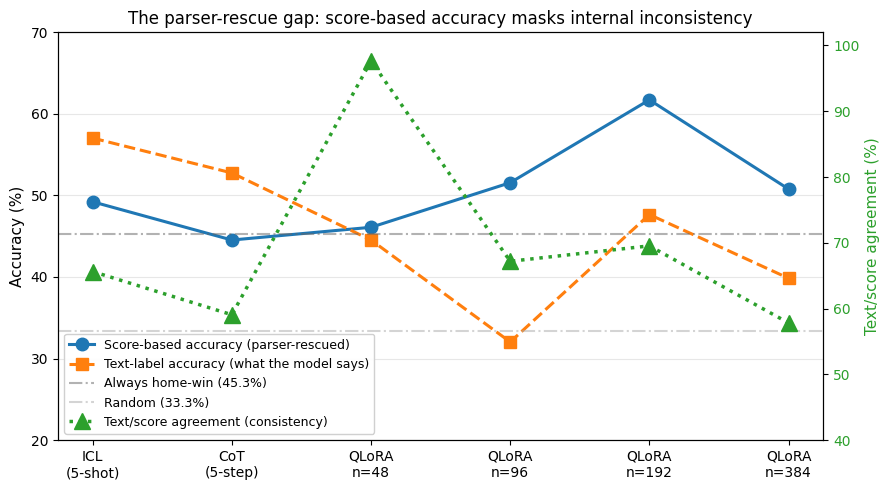

Saved consistency_curve.png


In [7]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# X positions — ICL, CoT as pseudo "n", then real n values on a log scale
cond_order = ['ICL', 'CoT', 'n48', 'n96', 'n192', 'n384']
xlabels = ['ICL\n(5-shot)', 'CoT\n(5-step)', 'QLoRA\nn=48', 'QLoRA\nn=96', 'QLoRA\nn=192', 'QLoRA\nn=384']
x = np.arange(len(cond_order))

score_accs = [table[c]['overall']['score_acc'] * 100 for c in cond_order]
text_accs  = [table[c]['overall']['text_acc']  * 100 for c in cond_order]
agreements = [table[c]['overall']['agreement'] * 100 for c in cond_order]

ax1.plot(x, score_accs, 'o-', color='#1f77b4', linewidth=2.2, markersize=9,
         label='Score-based accuracy (parser-rescued)')
ax1.plot(x, text_accs, 's--', color='#ff7f0e', linewidth=2.2, markersize=9,
         label='Text-label accuracy (what the model says)')
ax1.axhline(45.3, linestyle='-.', color='#666', alpha=0.5, label='Always home-win (45.3%)')
ax1.axhline(100/3, linestyle='-.', color='#aaa', alpha=0.5, label='Random (33.3%)')

ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, fontsize=10)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_ylim(20, 70)
ax1.grid(alpha=0.3, axis='y')

# Secondary axis for agreement
ax2 = ax1.twinx()
ax2.plot(x, agreements, '^:', color='#2ca02c', linewidth=2.5, markersize=11,
         label='Text/score agreement (consistency)')
ax2.set_ylabel('Text/score agreement (%)', fontsize=11, color='#2ca02c')
ax2.set_ylim(40, 102)
ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9, framealpha=0.92)

plt.title('The parser-rescue gap: score-based accuracy masks internal inconsistency',
          fontsize=12)
plt.tight_layout()
plt.savefig('consistency_curve.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved consistency_curve.png')


## 6. Figure B — named vs. anonymized consistency

Does fine-tuning on small data destroy internal consistency differently on named vs. anonymized inputs? If the anon line drops faster, the model is losing consistency specifically when pre-training priors are absent.


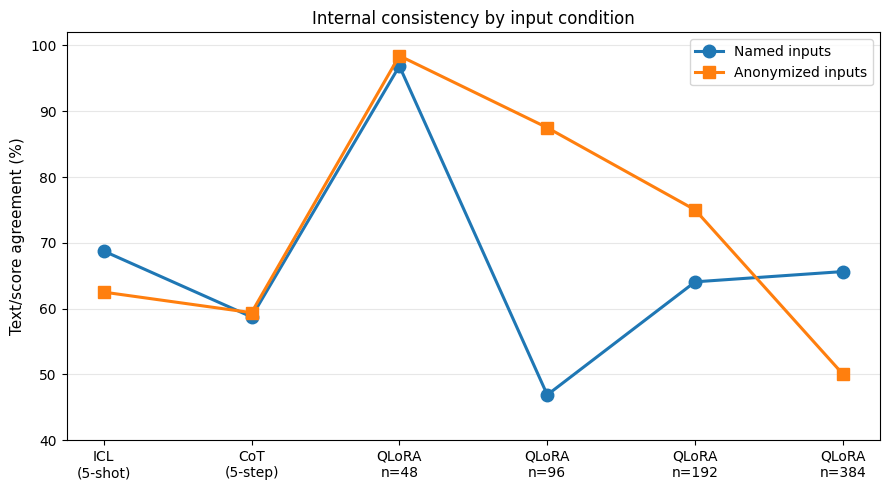

Saved consistency_by_split.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
named_agrees = [table[c]['named']['agreement'] * 100 if table[c]['named']['agreement'] else np.nan
                for c in cond_order]
anon_agrees  = [table[c]['anon']['agreement'] * 100 if table[c]['anon']['agreement'] else np.nan
                for c in cond_order]

ax.plot(x, named_agrees, 'o-', color='#1f77b4', linewidth=2.2, markersize=9, label='Named inputs')
ax.plot(x, anon_agrees,  's-', color='#ff7f0e', linewidth=2.2, markersize=9, label='Anonymized inputs')

ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel('Text/score agreement (%)', fontsize=11)
ax.set_title('Internal consistency by input condition', fontsize=12)
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=10)
ax.set_ylim(40, 102)
plt.tight_layout()
plt.savefig('consistency_by_split.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved consistency_by_split.png')


## 7. Table 2 — contradiction taxonomy with examples

We classify each sample's output into one of four regimes:

- **A (all-agree correct)**: text == score == GT, and reasoning argues for the same side → genuine success
- **B (all-agree wrong)**: text == score != GT → honest mistake, self-consistent
- **C (parser-rescued)**: text != score, score == GT → wrong reasoning but the `Score:` line happens to match GT
- **D (fragmented)**: text != score, neither matches GT, OR reasoning argues for a third side → fully decoupled

C is the failure mode that inflates standard metrics. D is the worst case.


In [9]:
def classify(r):
    t, s, g = r['text_label'], r['score_label'], r['gt']['result']
    ra = r['reasoning_arg']
    if t not in ('home_win', 'away_win', 'draw') or s not in ('home_win', 'away_win', 'draw'):
        return 'missing'
    if t == s == g:
        return 'A'  # all agree correct
    if t == s and t != g:
        return 'B'  # all agree wrong
    if t != s and s == g:
        return 'C'  # parser-rescued (text wrong, score right)
    if t != s and t == g:
        return 'C-inv'  # text right, score wrong (rare, interesting)
    return 'D'  # fragmented


for cond, data in results.items():
    for r in data:
        r['regime'] = classify(r)

# Summary per condition
print("=" * 80)
print(f"{'Cond':<8} {'A (all✓)':>10} {'B (all✗)':>10} {'C (rescued)':>12} {'C-inv':>8} {'D (frag)':>10} {'missing':>8}")
print("=" * 80)
regime_counts = {}
for cond in cond_order:
    data = results[cond]
    c = Counter(r['regime'] for r in data)
    regime_counts[cond] = dict(c)
    print(f"{cond:<8} {c.get('A',0):>10} {c.get('B',0):>10} {c.get('C',0):>12} "
          f"{c.get('C-inv',0):>8} {c.get('D',0):>10} {c.get('missing',0):>8}")
print("=" * 80)


Cond       A (all✓)   B (all✗)  C (rescued)    C-inv   D (frag)  missing
ICL              54         30            9       19         16        0
CoT              45         30           12       22         18        1
n48              57         68            2        0          1        0
n96              36         50           30        5          7        0
n192             54         35           25        7          7        0
n384             41         33           24       10         20        0


In [10]:
# Dump illustrative examples for each regime to a markdown file for the report
example_md = ['# Example contradictions for the report\n']

def format_example(r, tag):
    txt = r['raw_output'][:400]
    return (f"### {tag}: sample {r['sample_idx']} (condition), is_anon={r['is_anon']}\n"
            f"- **GT:** {r['gt']['result']} ({r['gt']['home_goals']}-{r['gt']['away_goals']})\n"
            f"- **Text label:** {r['text_label']}\n"
            f"- **Score label:** {r['score_label']}\n"
            f"- **Reasoning argues for:** {r['reasoning_arg']}\n"
            f"- **Regime:** {r['regime']}\n\n"
            f"```\n{txt}\n```\n\n")


# Pick ~2 examples per regime from each fine-tuning adapter
for cond in ['n96', 'n192', 'n384']:
    data = results[cond]
    for regime_name, desc in [('A', 'Genuine success (all three views agree, correct)'),
                              ('C', 'Parser-rescued (text wrong, score matches GT by luck)'),
                              ('D', 'Fragmented (text, score, reasoning all disagree)')]:
        example_md.append(f"\n## {cond} — Regime {regime_name}: {desc}\n")
        examples = [r for r in data if r['regime'] == regime_name][:2]
        for r in examples:
            example_md.append(format_example(r, cond))

with open('example_contradictions.md', 'w') as f:
    f.write('\n'.join(example_md))
print("Saved example_contradictions.md")


Saved example_contradictions.md


## 8. Consolidate all numbers for the report (one source of truth)

In [11]:
final = {
    'consistency_table': table,
    'regime_counts': regime_counts,
    'gt_distribution': {
        'home_win': sum(1 for r in results['n384'] if r['gt']['result'] == 'home_win'),
        'away_win': sum(1 for r in results['n384'] if r['gt']['result'] == 'away_win'),
        'draw':     sum(1 for r in results['n384'] if r['gt']['result'] == 'draw'),
        'total': len(results['n384']),
    },
    'baseline_numbers': {
        'base_llama_accuracy': 0.453,
        'always_home_accuracy': 0.453,
        'random_accuracy': 0.359,
    },
}
with open('final_tables.json', 'w') as f:
    json.dump(final, f, indent=2, default=str)
print("Saved final_tables.json — single source of truth for the report.")


Saved final_tables.json — single source of truth for the report.


## 9. Key numbers + the right interpretation

**The direction of the score_acc vs text_acc gap matters:**
- **score_acc > text_acc → parser rescue.** The model's `Score:` line accidentally matches GT more often than its `Prediction:` line. Credit is inflated.
- **text_acc > score_acc → parser penalty.** The model's `Prediction:` line is more reliable than its score line (which sometimes uses non-home-away format).

Both ICL and CoT show **text_acc > score_acc** — their text labels are *more* accurate than their scores. The parser penalizes them. Their reasoning and labels are coherent; the score format is occasionally violated.

All QLoRA adapters at n ≥ 96 show **score_acc > text_acc** by 10–20 points — the parser is *rescuing* them. The Prediction label and the Score line are decoupled generation events, and the evaluator happens to pick whichever happens to match GT.

This is the central finding: fine-tuning on small data learns the output *format* (Prediction/Score/Reasoning structure) but not the *binding* between the fields. Standard accuracy metrics mask this because the eval convention of `score > text` accidentally rewards whichever field is closer to GT, independently.


In [12]:
print("=" * 80)
print("KEY NUMBERS FOR THE REPORT")
print("=" * 80)

print("\n[Thesis-supporting numbers]")
print(f"  Text/score agreement:")
for c in cond_order:
    ag = table[c]['overall']['agreement'] * 100 if table[c]['overall']['agreement'] else None
    print(f"    {c:<8}: {ag:.1f}%" if ag else f"    {c:<8}: —")

print("\n  Score-acc vs text-acc gap (parser rescue):")
for c in cond_order:
    sa = table[c]['overall']['score_acc']
    ta = table[c]['overall']['text_acc']
    gap = (sa - ta) * 100 if sa is not None and ta is not None else None
    print(f"    {c:<8}: score {sa*100:.1f}% → text {ta*100:.1f}%   gap {gap:+.1f}pp")

print("\n  Home-win prediction rate (collapse indicator):")
for c in cond_order:
    hp = table[c]['overall']['home_pred_rate'] * 100
    print(f"    {c:<8}: {hp:.1f}%")

print("\n[Baseline references]")
print(f"  GT home_win rate: {final['gt_distribution']['home_win']}/{final['gt_distribution']['total']} = {final['gt_distribution']['home_win']/final['gt_distribution']['total']*100:.1f}%")
print(f"  Always home-win baseline: 45.3%")
print(f"  Random 3-class: 33.3%")

print("\n[Regime counts]")
for c in cond_order:
    rc = regime_counts[c]
    total = sum(rc.values())
    print(f"  {c}: A={rc.get('A',0)} B={rc.get('B',0)} C={rc.get('C',0)} D={rc.get('D',0)} (n={total})")


KEY NUMBERS FOR THE REPORT

[Thesis-supporting numbers]
  Text/score agreement:
    ICL     : 65.6%
    CoT     : 59.1%
    n48     : 97.7%
    n96     : 67.2%
    n192    : 69.5%
    n384    : 57.8%

  Score-acc vs text-acc gap (parser rescue):
    ICL     : score 49.2% → text 57.0%   gap -7.8pp
    CoT     : score 44.5% → text 52.8%   gap -8.2pp
    n48     : score 46.1% → text 44.5%   gap +1.6pp
    n96     : score 51.6% → text 32.0%   gap +19.5pp
    n192    : score 61.7% → text 47.7%   gap +14.1pp
    n384    : score 50.8% → text 39.8%   gap +10.9pp

  Home-win prediction rate (collapse indicator):
    ICL     : 82.0%
    CoT     : 99.2%
    n48     : 98.4%
    n96     : 21.1%
    n192    : 44.5%
    n384    : 51.6%

[Baseline references]
  GT home_win rate: 58/128 = 45.3%
  Always home-win baseline: 45.3%
  Random 3-class: 33.3%

[Regime counts]
  ICL: A=54 B=30 C=9 D=16 (n=128)
  CoT: A=45 B=30 C=12 D=18 (n=128)
  n48: A=57 B=68 C=2 D=1 (n=128)
  n96: A=36 B=50 C=30 D=7 (n=128)
